In [14]:
#FashionMNIST multi_output
#不变动位置
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset


print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all, random_state=22
)

data_map = {
    "train": (X_train, y_train),
    "val": (X_val, y_val),
    "test": (X_test, y_test)
}

scaler = StandardScaler()
scaler.fit(X_train)

class CaliforniaHousingDataset(Dataset):
    def __init__(self, mode):
        self.X ,self.y = data_map[mode]
        self.X = torch.from_numpy(scaler.transform(self.X)).float()
        self.y = torch.from_numpy(self.y).float().reshape(-1, 1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CaliforniaHousingDataset("train")
val_dataset = CaliforniaHousingDataset("val")
test_dataset = CaliforniaHousingDataset("test")

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.0
numpy 2.1.3
pandas 2.2.3
sklearn 1.8.0
torch 2.9.1+cu130
cuda:0


In [15]:
# 定义多输出模型

class WideDeep(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.deep = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 30),
            nn.ReLU()
        )
        self.out = nn.Linear(30 + input_dim, 1)
        
        self.init_weights()
    
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
                
    def forward(self, x, return_deep_output=False):
        deep_out = self.deep(x)
        concat = torch.cat([x, deep_out], dim=-1)
        logits = self.out(concat)
        return (logits,deep_out) if return_deep_output else logits

In [16]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = -1
        self.counter = 0
        
    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            # update best metric
            self.best_metric = metric
            # reset counter 
            self.counter = 0
        else: 
            self.counter += 1
            
    @property
    def early_stop(self):
        return self.counter >= self.patience


In [17]:
from sklearn.metrics import accuracy_score

@torch.no_grad()
def evaluating(model, data_loader, loss_fct):
    loss_list = []
    for datas, labels in data_loader:
        datas = datas.to(device)
        labels = labels.to(device)
        logits = model(datas)
        loss = loss_fct(logits, labels)
        loss_list.append(loss.item())
    return np.mean(loss_list)


In [18]:
def training(model, train_loader, val_loader, epoch, loss_fct, optimizer, tensorboard_callback=None,save_ckpt_callback=None,early_stop_callback=None,eval_step=500,):
    record_dict = {
        "train": [],
        "val": []
    }
    
    global_step = 0
    model.train()
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            for datas, labels in train_loader:
                datas = datas.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                logits, deep_output = model(datas,return_deep_output=True)
                deep_output= deep_output.mean(axis=1).reshape(-1, 1)
                logits=logits+deep_output
                loss = loss_fct(logits, labels)
                loss.backward()
                optimizer.step()
                loss = loss.cpu().item()
                
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })
                
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step
                    })
                    model.train()

                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict
                    
                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})
        
    return record_dict
        

epoch = 10

model = WideDeep()


loss_fct = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.0)

early_stop_callback = EarlyStopCallback(patience=10, min_delta=1e-3)

model = model.to(device)
record = training(model, train_loader, val_loader, epoch, loss_fct, optimizer, early_stop_callback=early_stop_callback,eval_step=len(train_loader))

  0%|          | 0/7260 [00:00<?, ?it/s]

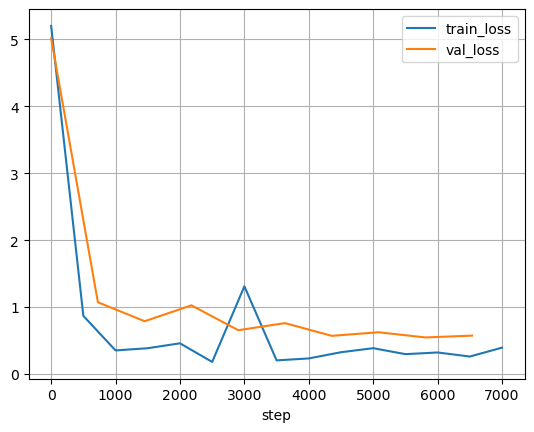

In [19]:
def plot_learning_curves(record_dict, sample_step=500):
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    for idx, item in enumerate(train_df.columns):
        plt.plot(train_df.index, train_df[item], label=f"train_{item}")
        plt.plot(val_df.index, val_df[item], label=f"val_{item}")
        plt.grid()
        plt.legend()
        plt.xlabel("step")
        plt.show()

plot_learning_curves(record, sample_step=500)